# Figure 1: genomic screening and locus architecture

Run this notebook from top to bottom. It reproduces panels **b** and **d** and documents the external iTOL rendering of panel **c**. The biochemical schematic in panel **a** is intentionally outside the scope of this package.

The originally named `figure 1a.ipynb` now corresponds to **Figure 1b**; the originally named `figure 1c.ipynb` now corresponds to **Figure 1d**. Original data bytes, numeric calculations, typography and plot dimensions are preserved. TIFF exports use lossless uncompressed storage. Inputs are read from `../data/figure1/` and outputs are written to `../outputs/figure1/` when run from `notebooks/`.

## Setup

In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import Polygon

# Run from the repository root or from the notebooks directory.
REPO_ROOT = Path("..") if Path.cwd().name == "notebooks" else Path(".")
DATA_DIR = REPO_ROOT / "data" / "figure1"
OUTPUT_DIR = REPO_ROOT / "outputs" / "figure1"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
assert DATA_DIR.is_dir(), "Run this notebook from the repository root or notebooks directory."


## Figure 1b: component co-occurrence

The packaged genome-level component indicators are aggregated into intersections using the original plotting code.

meta NOT subset; don't know how to subset; dropped


Exported: outputs\figure1\Figure1b_upset @ 90x70 mm


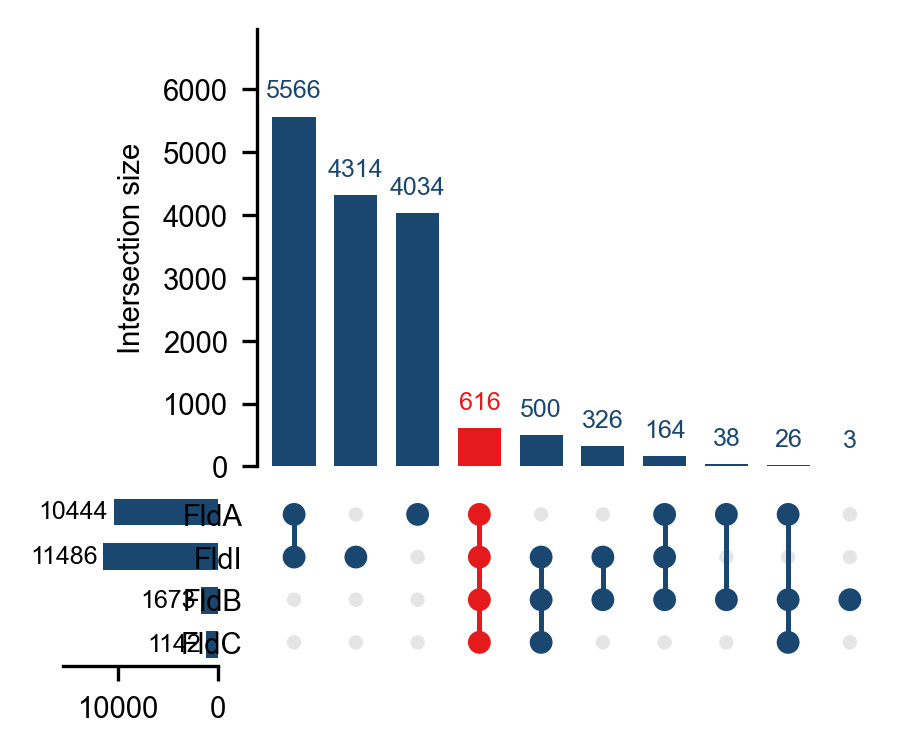

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# 1. Dimensions and Style
WIDTH_MM = 90
HEIGHT_MM = 70

mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans', 'sans-serif'],
    'pdf.fonttype': 42,
    'svg.fonttype': 'none',
    'font.size': 7,
    'axes.labelsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'axes.spines.right': False,
    'axes.spines.top': False,
    'axes.linewidth': 0.8,
    'figure.facecolor': 'white',
})

# 2. Load the packaged Figure 1b input
source_file = DATA_DIR / 'Figure1b_upset_data.tsv'

# 3. Read and Prepare Data
df = pd.read_csv(source_file, sep='\t')
df_pos = df[(df['FldA_PF02515'] > 0) | (df['FldI_PF01869'] > 0) | (df['FldBC_PF06050'] > 0)].copy()

# Enforce strictly binary indicators
df_pos['FldA'] = (df_pos['FldA_PF02515'] > 0).astype(int)
df_pos['FldI'] = (df_pos['FldI_PF01869'] > 0).astype(int)
df_pos['FldB'] = (df_pos['FldBC_PF06050'] > 0).astype(int)
df_pos['FldC'] = (df_pos['FldBC_ge2_subunits'] > 0).astype(int)

# Defined in explicit top-to-bottom order
SUBUNITS = ['FldA', 'FldI', 'FldB', 'FldC']
SUBUNIT_LABELS = {
    'FldA': 'FldA',
    'FldI': 'FldI',
    'FldB': 'FldB',
    'FldC': 'FldC'
}

# Aggregate combinations
combo_counts = df_pos.groupby(SUBUNITS).size().reset_index(name='n_genomes')
combo_counts = combo_counts.sort_values('n_genomes', ascending=False).reset_index(drop=True)
left_counts = [df_pos[sub].sum() for sub in SUBUNITS]

# 4. Initialize Plot
fig = plt.figure(figsize=(WIDTH_MM / 25.4, HEIGHT_MM / 25.4), dpi=300)

gs = fig.add_gridspec(2, 2, width_ratios=[0.7, 2.85], height_ratios=[2.5, 1.0], wspace=0.10, hspace=0.08)

ax_empty = fig.add_subplot(gs[0, 0])
ax_top = fig.add_subplot(gs[0, 1])
ax_left = fig.add_subplot(gs[1, 0])
ax_matrix = fig.add_subplot(gs[1, 1])
ax_empty.axis('off')

# Colour palette
COLOR_DEFAULT = "#1A476F"
COLOR_RED = "#e41a1c"
COLOR_BG = "#E5E5E5"

x = np.arange(len(combo_counts))
genome_counts = combo_counts['n_genomes'].to_numpy()

# ==================== TOP BAR CHART ====================
bar_colors = [COLOR_RED if row[SUBUNITS].sum() == 4 else COLOR_DEFAULT for _, row in combo_counts.iterrows()]
ax_top.bar(x, genome_counts, color=bar_colors, width=0.7)

for xi, (n, color) in enumerate(zip(genome_counts, bar_colors)):
    # Scale the label offset to the maximum intersection count.
    ax_top.text(xi, n + genome_counts.max() * 0.04, str(n), ha='center', va='bottom', fontsize=6, color=color)

ax_top.set_ylabel('Intersection size', fontsize=7)
ax_top.set_xticks([])
ax_top.set_xlim(-0.6, len(combo_counts) - 0.4)

# Scale the y-axis range to the maximum intersection count.
ax_top.set_ylim(0, genome_counts.max() * 1.25)

ax_top.spines['bottom'].set_visible(False)

# ==================== UPSET MATRIX ====================
y_positions = np.arange(len(SUBUNITS))
DOT_SIZE_BG = 12
DOT_SIZE_FG = 30

for yi, sub in enumerate(SUBUNITS):
    ax_matrix.scatter(x, np.full_like(x, yi), s=DOT_SIZE_BG, color=COLOR_BG, edgecolor='none', zorder=1)

for i, row in combo_counts.iterrows():
    ys = [yi for yi, sub in enumerate(SUBUNITS) if row[sub] == 1]
    is_all_4 = len(ys) == 4
    c = COLOR_RED if is_all_4 else COLOR_DEFAULT

    if len(ys) >= 2:
        ax_matrix.plot([i, i], [min(ys), max(ys)], color=c, lw=1.2, zorder=2)
    
    ax_matrix.scatter([i]*len(ys), ys, s=DOT_SIZE_FG, color=c, edgecolor='none', zorder=3)

ax_matrix.set_yticks(y_positions)
ax_matrix.set_yticklabels([SUBUNIT_LABELS[s] for s in SUBUNITS], fontsize=7)
ax_matrix.set_xticks([])
ax_matrix.set_xlim(-0.6, len(combo_counts) - 0.4)
ax_matrix.set_ylim(-0.55, len(SUBUNITS) - 0.45)
ax_matrix.invert_yaxis()
for side in ['top', 'right', 'bottom', 'left']:
    ax_matrix.spines[side].set_visible(False)
ax_matrix.tick_params(axis='both', length=0)

# ==================== LEFT BAR CHART ====================
ax_left.barh(y_positions, left_counts, color=COLOR_DEFAULT, height=0.6)
max_count = max(left_counts)
ax_left.set_xlim(max_count * 1.35, 0)

for yi, n in enumerate(left_counts):
    ax_left.text(n + max_count * 0.05, yi, str(n), va='center', ha='right', fontsize=6)

ax_left.set_yticks([])
ax_left.set_xlabel('')
ax_left.invert_yaxis()
for side in ['top', 'right', 'left']:
    ax_left.spines[side].set_visible(False)

# 5. Export
out_stem = OUTPUT_DIR / 'Figure1b_upset'
fig.savefig(f"{out_stem}.pdf", bbox_inches='tight')
fig.savefig(f"{out_stem}.png", dpi=300, bbox_inches='tight')
print(f"Exported: {out_stem} @ {WIDTH_MM}x{HEIGHT_MM} mm")
plt.show()

## Figure 1c: phylogeny rendered in iTOL

The tree is not redrawn with Python. Import `../data/figure1/itol/tree_FldBC_concat.nwk` into [iTOL](https://itol.embl.de/), then upload `01_labels.txt`, `02_tree_colors.txt`, `03_strip_phylum.txt`, `04_strip_family.txt` and `05_symbol_status.txt`. Export the final tree to `../outputs/figure1/`.

`FldBC_concat_iqtree.treefile` is an identical copy of the primary tree. Additional FldA, FldB, FldC and FldI FastTree files and the FldB IQ-TREE file are supplied as supporting trees. Appearance settings such as layout, scale and annotation widths are configured in iTOL; the annotation files alone do not encode every setting of the final manuscript export.

In [3]:
# Inspect the packaged Figure 1c tree and iTOL annotation files.
TREE_DIR = DATA_DIR / "itol"
TREE_FILE = TREE_DIR / "tree_FldBC_concat.nwk"
ANNOTATION_FILES = [
    TREE_DIR / "01_labels.txt", TREE_DIR / "02_tree_colors.txt",
    TREE_DIR / "03_strip_phylum.txt", TREE_DIR / "04_strip_family.txt",
    TREE_DIR / "05_symbol_status.txt",
]
assert TREE_FILE.is_file()
assert all(path.is_file() for path in ANNOTATION_FILES)
print("Figure 1c primary tree:", TREE_FILE.relative_to(REPO_ROOT).as_posix())
print("iTOL annotations:", ", ".join(path.name for path in ANNOTATION_FILES))


Figure 1c primary tree: data/figure1/itol/tree_FldBC_concat.nwk
iTOL annotations: 01_labels.txt, 02_tree_colors.txt, 03_strip_phylum.txt, 04_strip_family.txt, 05_symbol_status.txt


## Figure 1d: accessory-gene positions and representative loci

The upper and lower components are exported separately as `Figure1d1_positional_frequency` and `Figure1d2_synteny_tracks`, respectively. They retain the source notebook's dimensions and gene-order checks.

In [4]:
def set_pub_style():
    """Sets publication typography and rendering defaults according to Nature standards."""
    mpl.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
        'pdf.fonttype': 42,
        'ps.fonttype': 42,
        'svg.fonttype': 'none',
        'font.size': 6,
        'axes.labelsize': 6,
        'axes.titlesize': 6,
        'xtick.labelsize': 6,
        'ytick.labelsize': 6,
        'legend.fontsize': 6,
        'legend.title_fontsize': 6,
        'axes.linewidth': 0.8,
        'xtick.major.width': 0.8,
        'ytick.major.width': 0.8,
        'xtick.major.size': 2.5,
        'ytick.major.size': 2.5,
        'lines.linewidth': 1.0,
        'patch.linewidth': 0.6,
    })

COLORS = {
    # Core Operon genes (Nature Red)
    'FldA': '#E64B35',
    'FldI': '#E64B35',
    'FldB': '#E64B35',
    'FldC': '#E64B35',
    'FldBC': '#E64B35',
    
    # Accessory metabolic genes
    'FldH': '#4DBBD5',     # Cyan / Light blue (Dehydrogenase)
    'AcdA': '#00A087',     # Teal / Green (Acyl-CoA dehydrogenase)
    'EtfB': '#8491B4',     # Slate blue (Electron transfer beta subunit)
    'EtfA': '#3C5488',     # Navy / Blue (Electron transfer alpha subunit)
    'FldX': '#E79F24',     # Amber (MFS transporter)
    'Other': '#E0E0E0',    # Neutral light grey
}

def draw_gene_arrow(ax, x_start, x_end, y_center, height=0.38, strand='+', color='#E0E0E0', label='', label_color='white', fontsize=6.0):
    """Draws a crisp genomic arrow patch in kb coordinates."""
    width = x_end - x_start
    arrow_head_len = min(abs(width) * 0.35, 0.32)
    
    if strand == '+' or strand == 1:
        head_x = x_end
        base_x = x_start
        body_end = x_end - arrow_head_len
        verts = [
            (base_x, y_center - height/2),
            (body_end, y_center - height/2),
            (body_end, y_center - height*0.75),
            (head_x, y_center),
            (body_end, y_center + height*0.75),
            (body_end, y_center + height/2),
            (base_x, y_center + height/2),
        ]
    else:
        head_x = x_start
        base_x = x_end
        body_end = x_start + arrow_head_len
        verts = [
            (base_x, y_center - height/2),
            (body_end, y_center - height/2),
            (body_end, y_center - height*0.75),
            (head_x, y_center),
            (body_end, y_center + height*0.75),
            (body_end, y_center + height/2),
            (base_x, y_center + height/2),
        ]
    
    poly = Polygon(verts, closed=True, facecolor=color, edgecolor='#333333', linewidth=0.5, zorder=3)
    ax.add_patch(poly)
    
    if label:
        ax.text((x_start + x_end)/2, y_center, label, color=label_color,
                ha='center', va='center', fontsize=fontsize, weight='bold', zorder=4, fontname='Arial')

def save_pub_figure(fig, output_stem, width_mm=92, height_mm=92, dpi=600):
    """Export vector figures and lossless raster figures to the output directory."""
    fig.set_size_inches(width_mm / 25.4, height_mm / 25.4)
    for extension, options in (
        ("svg", {}), ("pdf", {}), ("png", {"dpi": 300}),
        ("tiff", {"dpi": dpi, "pil_kwargs": {"compression": "raw"}}),
    ):
        fig.savefig(f"{output_stem}.{extension}", bbox_inches="tight", transparent=False, **options)
    print(f"Exported: {Path(output_stem).name} (SVG, PDF, PNG, TIFF)")

### Upper component: positional frequencies

meta NOT subset; don't know how to subset; dropped


meta NOT subset; don't know how to subset; dropped


Exported: Figure1d1_positional_frequency (SVG, PDF, PNG, TIFF)


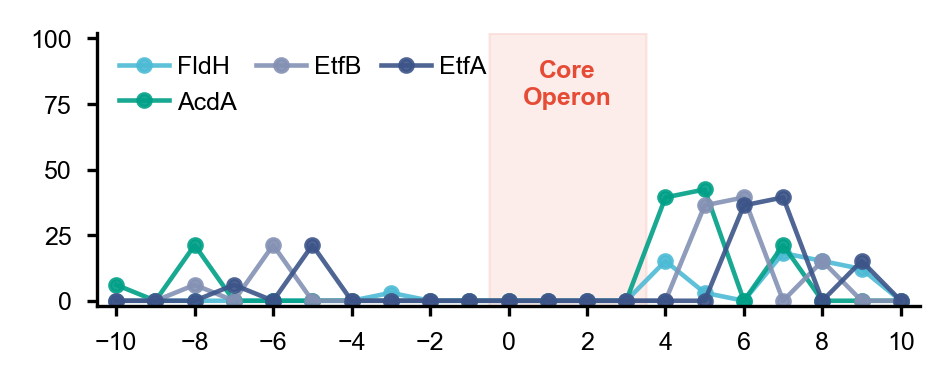

In [5]:
# Figure 1d, upper component: Positional Frequency of Flanking Genes
WIDTH_MM = 90
HEIGHT_MM = 30
set_pub_style()

src_pos = DATA_DIR / 'Figure1d1_positional_frequency.tsv'
df_pos = pd.read_csv(src_pos, sep='\t')

fig, ax = plt.subplots(figsize=(WIDTH_MM/25.4, HEIGHT_MM/25.4), dpi=300)
# Plot the four accessory genes shown in the final panel.
plot_genes = ['FldH', 'AcdA', 'EtfB', 'EtfA'] 
df_fld_pos = df_pos[df_pos['lineage'] == 'Fld_Lineage'].copy()
positions = np.arange(-10, 11)

for gene in plot_genes:
    sub = df_fld_pos[df_fld_pos['gene'] == gene].set_index('relative_pos').reindex(positions, fill_value=0)
    ax.plot(positions, sub['frequency_pct'], marker='o', markersize=3.0, 
            label=gene, color=COLORS.get(gene, '#7F7F7F'), linewidth=1.1, alpha=0.9)

ax.axvspan(-0.5, 3.5, color=COLORS['FldA'], alpha=0.10, zorder=0)
ax.text(1.5, 92, 'Core\nOperon', ha='center', va='top', fontsize=6.0, color=COLORS['FldA'], weight='bold', fontname='Arial')
ax.set_xlim(-10.5, 10.5)
ax.set_ylim(-2, 102)
ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='upper left', frameon=False, ncol=3, columnspacing=0.8, handletextpad=0.3, fontsize=6.0)

out_stem = OUTPUT_DIR / 'Figure1d1_positional_frequency'
save_pub_figure(fig, out_stem, width_mm=WIDTH_MM, height_mm=HEIGHT_MM)
plt.show()

### Lower component: representative synteny tracks

meta NOT subset; don't know how to subset; dropped


meta NOT subset; don't know how to subset; dropped


meta NOT subset; don't know how to subset; dropped


Exported: Figure1d2_synteny_tracks (SVG, PDF, PNG, TIFF)


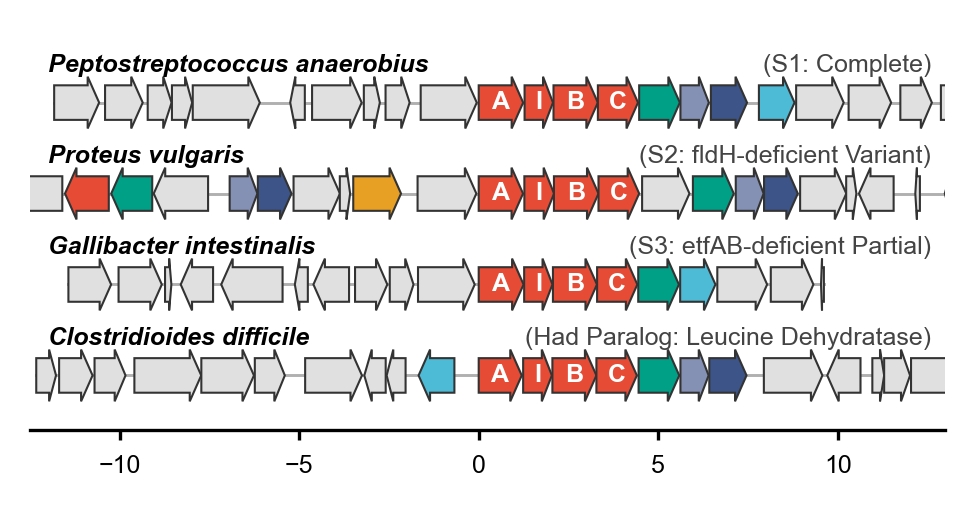

In [6]:
# Figure 1d, lower component: 4 Representative Synteny Tracks (Clean Text, 6pt Typography)
WIDTH_MM = 100
HEIGHT_MM = 44
set_pub_style()

src_cds = DATA_DIR / 'Figure1d2_representative_synteny_tracks.tsv'
df_cds = pd.read_csv(src_cds, sep='\t')

fig, ax = plt.subplots(
    figsize=(WIDTH_MM/25.4, HEIGHT_MM/25.4),
    dpi=300
)

rep_strains = [
    ('GCF_000178095.1',
     'Peptostreptococcus anaerobius',
     'S1: Complete'),

    ('GCF_025200655.1',
     'Proteus vulgaris',
     'S2: fldH-deficient Variant'),

    ('GCF_014982745.1',
     'Gallibacter intestinalis',
     'S3: etfAB-deficient Partial'),

    ('GCF_018885085.1',
     'Clostridioides difficile',
     'Had Paralog: Leucine Dehydratase'),
]

y_positions = [3, 2, 1, 0]

core_genes = ['FldA', 'FldI', 'FldB', 'FldC']

for (gcf, species, note), y_pos in zip(rep_strains, y_positions):

    sub_cds = df_cds[
        df_cds['genome_accession'] == gcf
    ].copy()

    if sub_cds.empty:
        continue

    # ---------------------------------------------------------
    # Identify fldAIBC core
    # ---------------------------------------------------------
    core_cds = sub_cds[
        (sub_cds['is_core'] == 'yes') &
        (sub_cds['assigned_gene'].isin(core_genes))
    ].copy()

    fldA_cds = core_cds[
        core_cds['assigned_gene'] == 'FldA'
    ]

    if fldA_cds.empty:
        raise ValueError(
            f"{gcf}: no core FldA found"
        )

    fldA_row = fldA_cds.iloc[0]

    # ---------------------------------------------------------
    # Orient all loci so that:
    #
    # FldA -> FldI -> FldB -> FldC
    #
    # is always LEFT -> RIGHT.
    #
    # FldA transcriptional start = x = 0
    # ---------------------------------------------------------
    core_strand = fldA_row['strand']

    if core_strand == '+':

        # Positive-strand locus:
        # FldA genomic start is its transcriptional start.
        ref_5p = fldA_row['start']

        sub_cds['x_s'] = (
            sub_cds['start'] - ref_5p
        ) / 1000.0

        sub_cds['x_e'] = (
            sub_cds['end'] - ref_5p
        ) / 1000.0

        sub_cds['plot_strand'] = sub_cds['strand']

    else:

        # Negative-strand locus:
        # FldA genomic end is its transcriptional start.
        # Reverse the coordinate system so A-I-B-C
        # is displayed left -> right.
        ref_5p = fldA_row['end']

        sub_cds['x_s'] = (
            ref_5p - sub_cds['end']
        ) / 1000.0

        sub_cds['x_e'] = (
            ref_5p - sub_cds['start']
        ) / 1000.0

        sub_cds['plot_strand'] = (
            sub_cds['strand']
            .map({
                '-': '+',
                '+': '-'
            })
        )

    # ---------------------------------------------------------
    # Verify A-I-B-C order after orientation
    # ---------------------------------------------------------
    oriented_core = sub_cds[
        (sub_cds['is_core'] == 'yes') &
        (sub_cds['assigned_gene'].isin(core_genes))
    ].copy()

    oriented_core['gene_center'] = (
        oriented_core['x_s'] +
        oriented_core['x_e']
    ) / 2.0

    core_centers = {
        gene: oriented_core.loc[
            oriented_core['assigned_gene'] == gene,
            'gene_center'
        ].iloc[0]
        for gene in core_genes
    }

    if not (
        core_centers['FldA']
        < core_centers['FldI']
        < core_centers['FldB']
        < core_centers['FldC']
    ):
        raise ValueError(
            f"{gcf}: fldAIBC order is not A-I-B-C "
            f"after orientation: {core_centers}"
        )

    # ---------------------------------------------------------
    # Draw genomic backbone
    # ---------------------------------------------------------
    min_x = sub_cds['x_s'].min()
    max_x = sub_cds['x_e'].max()

    ax.plot(
        [min_x, max_x],
        [y_pos, y_pos],
        color='#B0B0B0',
        linewidth=0.7,
        zorder=1
    )

    # ---------------------------------------------------------
    # Draw CDS arrows
    # ---------------------------------------------------------
    for _, row in sub_cds.iterrows():

        x_s = row['x_s']
        x_e = row['x_e']
        strand = row['plot_strand']
        gene_name = row['assigned_gene']

        c = COLORS.get(
            gene_name,
            COLORS['Other']
        )

        disp_label = ''

        if (
            gene_name in core_genes
            and row['is_core'] == 'yes'
        ):
            disp_label = gene_name[-1]

        draw_gene_arrow(
            ax,
            x_s,
            x_e,
            y_pos,
            height=0.38,
            strand=strand,
            color=c,
            label=disp_label,
            fontsize=6.0
        )

    # ---------------------------------------------------------
    # Species and architecture labels
    # ---------------------------------------------------------
    ax.text(
        -12.0,
        y_pos + 0.28,
        species,
        fontstyle='italic',
        fontsize=6.0,
        weight='bold',
        va='bottom',
        ha='left',
        fontname='Arial'
    )

    ax.text(
        12.6,
        y_pos + 0.28,
        f"({note})",
        fontsize=6.0,
        color='#444444',
        va='bottom',
        ha='right',
        fontname='Arial'
    )

# -------------------------------------------------------------
# Keep original panel dimensions / formatting unchanged
# -------------------------------------------------------------
ax.set_xlim(-12.5, 13.0)
ax.set_ylim(-0.6, 3.8)

ax.set_yticks([])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

out_stem = OUTPUT_DIR / 'Figure1d2_synteny_tracks'

save_pub_figure(
    fig,
    out_stem,
    width_mm=WIDTH_MM,
    height_mm=HEIGHT_MM
)

plt.show()